In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels for detailed statistical summaries (like p-values, R-squared)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scikit-learn for Machine Learning models and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score, classification_report, roc_curve, auc

# Set plot style
sns.set_theme(style="whitegrid")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
file_path = '/content/drive/MyDrive/ai_job_dataset.csv'
df = pd.read_csv(file_path)

In [5]:
# Display the first few rows and check data types
display(df.head())
display(df.info())

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

None

In [6]:
# Drop rows with missing values (Standard practice from Problem Set 7)
df = df.dropna()

In [7]:
# 2. DATA PREPROCESSING
columns_to_keep = ['salary_usd', 'years_experience', 'benefits_score',
                   'experience_level', 'education_required', 'company_size', 'remote_ratio']
df_clean = df[columns_to_keep].copy()

# Create a binary target for Classification (Problem Set 6)
# 1 if fully remote (100), 0 otherwise
df_clean['is_remote'] = (df_clean['remote_ratio'] == 100).astype(int)
df_clean = df_clean.drop('remote_ratio', axis=1) # Drop original after conversion

# Convert Categorical Variables to Dummy Variables (Problem Set 3)
# drop_first=True helps avoid perfect multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df_clean, columns=['experience_level', 'education_required', 'company_size'], drop_first=True)

# Separate Target Variables
# Y_reg for Regression (Predicting Salary)
Y_reg = df_encoded['salary_usd']
# Y_class for Classification (Predicting if Remote)
Y_class = df_encoded['is_remote']

# X for predictors
X = df_encoded.drop(['salary_usd', 'is_remote'], axis=1)

# Split data: 80% Train, 20% Test (As seen in Problem Sets 5, 6, 7)
X_train, X_test, y_reg_train, y_reg_test, y_class_train, y_class_test = train_test_split(
    X, Y_reg, Y_class, test_size=0.2, random_state=123
)

# Standardize the features (Crucial for KNN, Ridge, LASSO)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Data Preprocessing Complete. X_train shape:", X_train_scaled.shape)

Data Preprocessing Complete. X_train shape: (12000, 10)


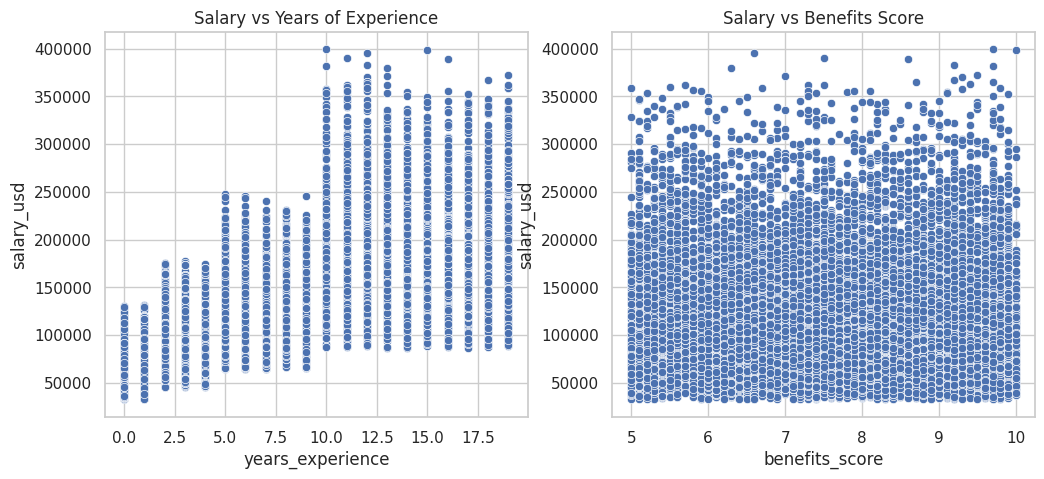

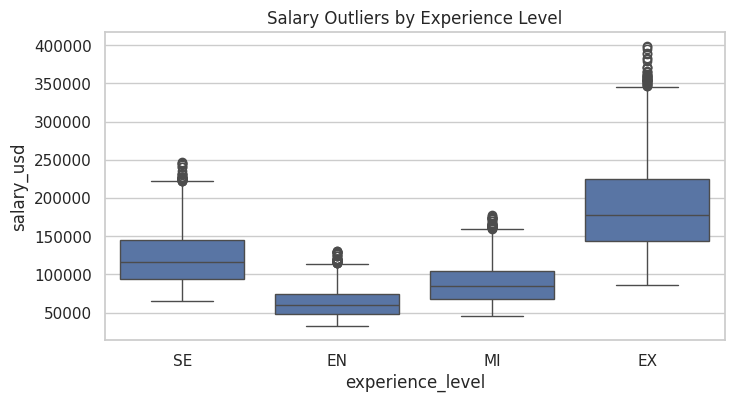

--- Variance Inflation Factor (VIF) ---
                        Feature        VIF
0                         const   1.000000
1              years_experience  11.053578
2                benefits_score   1.000929
3           experience_level_EX  14.675702
4           experience_level_MI   1.945398
5           experience_level_SE   4.344362
6   education_required_Bachelor   1.494857
7     education_required_Master   1.493119
8        education_required_PhD   1.484568
9                company_size_M   1.338104
10               company_size_S   1.338929


In [8]:
# 1. Scatter Plots (PS1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='years_experience', y='salary_usd', data=df_clean)
plt.title('Salary vs Years of Experience')

plt.subplot(1, 2, 2)
sns.scatterplot(x='benefits_score', y='salary_usd', data=df_clean)
plt.title('Salary vs Benefits Score')
plt.show()

# 2. Boxplot for Outliers (PS1 & PS4)
plt.figure(figsize=(8, 4))
sns.boxplot(x='experience_level', y='salary_usd', data=df_clean)
plt.title('Salary Outliers by Experience Level')
plt.show()

# 3. Variance Inflation Factor (VIF) for Multicollinearity (PS4)
print("--- Variance Inflation Factor (VIF) ---")
# Add a constant for VIF calculation
X_vif = sm.add_constant(X_train_scaled)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

In [9]:
#  REGRESSION MODELS (Target: salary_usd)
print("--- 1. Multiple Linear Regression (Statsmodels) ---")
# Using Statsmodels to get the detailed summary table (p-values, R-squared)
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)
ols_model = sm.OLS(y_reg_train.values, X_train_sm).fit()
print(ols_model.summary())

# Calculate Test MSE for OLS
ols_preds = ols_model.predict(X_test_sm)
ols_mse = mean_squared_error(y_reg_test, ols_preds)
print(f"\nOLS Test MSE: {ols_mse:.2f}")


print("\n--- 2. KNN Regression (k=5) ---")
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_reg_train)
knn_preds = knn_reg.predict(X_test_scaled)
knn_mse = mean_squared_error(y_reg_test, knn_preds)
print(f"KNN (k=5) Test MSE: {knn_mse:.2f}")


print("\n--- 3. LASSO Regression (Shrinkage) ---")
# Alpha is equivalent to Lambda in your course notes
lasso = Lasso(alpha=100.0, random_state=123)
lasso.fit(X_train_scaled, y_reg_train)
lasso_preds = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_reg_test, lasso_preds)
print(f"LASSO Test MSE: {lasso_mse:.2f}")

# Show which features LASSO kept vs shrank to zero
lasso_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})
print("\nLASSO Coefficients (Notice which are reduced to 0):")
print(lasso_coefs)

--- 1. Multiple Linear Regression (Statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     2168.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:57:38   Log-Likelihood:            -1.4289e+05
No. Observations:               12000   AIC:                         2.858e+05
Df Residuals:                   11989   BIC:                         2.859e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

--- 1. Logistic Regression ---
Confusion Matrix:
[[2053    0]
 [ 947    0]]
Test Accuracy: 0.6843

--- 2. KNN Classification (k=5) ---
KNN Confusion Matrix:
[[1616  437]
 [ 752  195]]
KNN Test Accuracy: 0.6037

--- 3. Naive Bayes Classification ---
Naive Bayes Test Accuracy: 0.6843


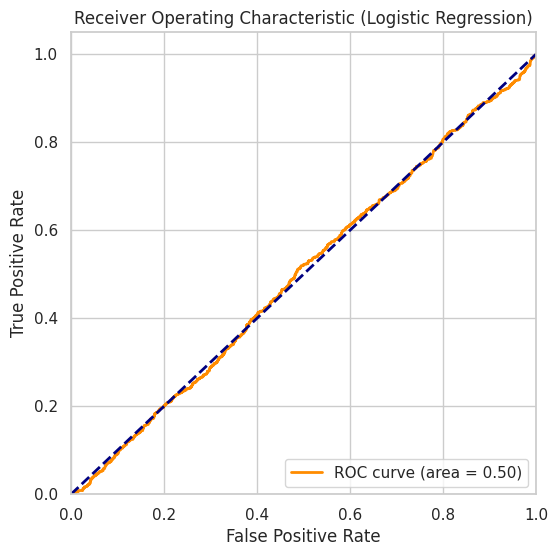

In [10]:
#CLASSIFICATION MODELS (Target: is_remote)
print("--- 1. Logistic Regression ---")
log_reg = LogisticRegression(random_state=123)
log_reg.fit(X_train_scaled, y_class_train)
log_preds = log_reg.predict(X_test_scaled)
log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_class_test, log_preds))
print(f"Test Accuracy: {accuracy_score(y_class_test, log_preds):.4f}")


print("\n--- 2. KNN Classification (k=5) ---")
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_class_train)
knn_clf_preds = knn_clf.predict(X_test_scaled)
print("KNN Confusion Matrix:")
print(confusion_matrix(y_class_test, knn_clf_preds))
print(f"KNN Test Accuracy: {accuracy_score(y_class_test, knn_clf_preds):.4f}")


print("\n--- 3. Naive Bayes Classification ---")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_class_train)
nb_preds = nb_model.predict(X_test_scaled)
print(f"Naive Bayes Test Accuracy: {accuracy_score(y_class_test, nb_preds):.4f}")

# ROC Curve for Logistic Regression
fpr, tpr, thresholds = roc_curve(y_class_test, log_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Logistic Regression)')
plt.legend(loc="lower right")
plt.show()

Dimension of coefficient matrix: (100, 10) (100 lambdas, 10 predictors)
L2 Norm at 50th lambda (alpha=9.33): 64468.86
L2 Norm at 60th lambda (alpha=37.65): 61922.69
-> Notice how the L2 norm shrinks as Lambda increases!



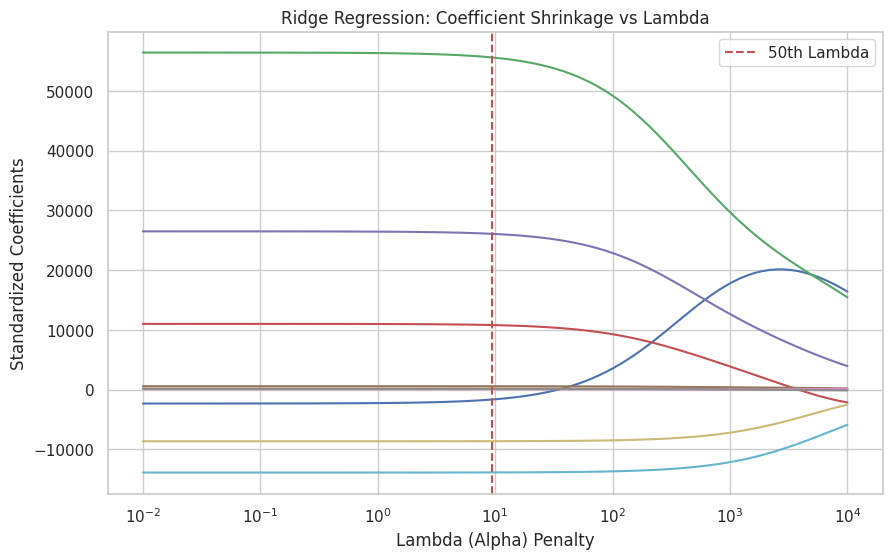


Optimal Lambda (Alpha) chosen by Cross-Validation: 2.01
Test MSE with Optimal Ridge Model: 1,330,048,059.69


In [12]:

# RIDGE REGRESSION & CROSS-VALIDATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error

cols = ['salary_usd', 'years_experience', 'benefits_score', 'experience_level', 'education_required', 'company_size']
df_encoded = pd.get_dummies(df[cols], drop_first=True)

X = df_encoded.drop('salary_usd', axis=1)
y = df_encoded['salary_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Scaling is MANDATORY for Ridge Regression so penalties apply equally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Fit Ridge with a Grid of Alphas (Lambda) ---
# Creating a grid of 100 lambda values from 0.01 to 10,000
alphas = np.logspace(-2, 4, 100)
coefs = []
l2_norms = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)
    # Calculate l2 norm (Euclidean length) of the coefficients
    l2_norms.append(np.linalg.norm(ridge.coef_))

# (i) Dimension of the coefficient matrix
print(f"Dimension of coefficient matrix: {np.array(coefs).shape} (100 lambdas, {X_train.shape[1]} predictors)")

# (ii) L2 norm for the 50th and 60th choice of lambda
print(f"L2 Norm at 50th lambda (alpha={alphas[49]:.2f}): {l2_norms[49]:.2f}")
print(f"L2 Norm at 60th lambda (alpha={alphas[59]:.2f}): {l2_norms[59]:.2f}")
print("-> Notice how the L2 norm shrinks as Lambda increases!\n")

# --- 3. Plotting Standardized Coefficients vs Lambda (Alpha) ---
plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log') # Log scale helps visualize the wide range of lambdas
plt.xlabel('Lambda (Alpha) Penalty')
plt.ylabel('Standardized Coefficients')
plt.title('Ridge Regression: Coefficient Shrinkage vs Lambda')
plt.axvline(x=alphas[49], color='r', linestyle='--', label='50th Lambda')
plt.legend(loc='best')
plt.show()

# --- 4. Cross-Validation to find the OPTIMAL Lambda ---
# RidgeCV tests our grid of alphas and automatically picks the best one using Cross-Validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

optimal_alpha = ridge_cv.alpha_
print(f"\nOptimal Lambda (Alpha) chosen by Cross-Validation: {optimal_alpha:.2f}")

# --- 5. Final Test MSE with Optimal Lambda ---
best_ridge = Ridge(alpha=optimal_alpha)
best_ridge.fit(X_train_scaled, y_train)
best_preds = best_ridge.predict(X_test_scaled)
best_mse = mean_squared_error(y_test, best_preds)

print(f"Test MSE with Optimal Ridge Model: {best_mse:,.2f}")

In [13]:

# ELASTIC NET REGRESSION (Problem Set 7)
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error

print("--- Elastic Net Regression (Cross-Validated) ---")

# ElasticNetCV tests different combinations of L1 (LASSO) and L2 (Ridge) ratios
# l1_ratio = 0.5 means a 50/50 mix of Ridge and LASSO
elastic_net_cv = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
                              cv=5, random_state=123)

# Fit the model using the scaled training data from earlier cells
elastic_net_cv.fit(X_train_scaled, y_reg_train)

# Predict and calculate MSE
en_preds = elastic_net_cv.predict(X_test_scaled)
en_mse = mean_squared_error(y_reg_test, en_preds)

print(f"Optimal L1 Ratio chosen: {elastic_net_cv.l1_ratio_}")
print(f"Optimal Alpha chosen: {elastic_net_cv.alpha_:.2f}")
print(f"Elastic Net Test MSE: {en_mse:,.2f}")

# Show non-zero coefficients
en_coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': elastic_net_cv.coef_})
print("\nElastic Net Non-Zero Coefficients:")
print(en_coefs[en_coefs['Coefficient'] != 0])

--- Elastic Net Regression (Cross-Validated) ---
Optimal L1 Ratio chosen: 1.0
Optimal Alpha chosen: 117.78
Elastic Net Test MSE: 1,329,729,554.29

Elastic Net Non-Zero Coefficients:
                       Feature   Coefficient
1               benefits_score     58.257559
2          experience_level_EX  53506.252377
3          experience_level_MI  10185.990170
4          experience_level_SE  24952.302531
5  education_required_Bachelor    384.746941
8               company_size_M  -8414.701827
9               company_size_S -13641.642426


In [15]:

# INTERACTION TERMS (Problem Set 3)

import statsmodels.api as sm

print("--- Testing Interaction Terms ---")

# Create a clean DataFrame using the ALREADY EXISTING 'is_remote' column
df_interact = df_clean[['salary_usd', 'years_experience', 'is_remote']].copy()

# Create the Interaction Term (Years Experience * Is Remote)
df_interact['experience_x_remote'] = df_interact['years_experience'] * df_interact['is_remote']

# 1. Model WITHOUT Interaction Term
X_no_interact = sm.add_constant(df_interact[['years_experience', 'is_remote']])
model_no_interact = sm.OLS(df_interact['salary_usd'], X_no_interact).fit()

# 2. Model WITH Interaction Term
X_with_interact = sm.add_constant(df_interact[['years_experience', 'is_remote', 'experience_x_remote']])
model_with_interact = sm.OLS(df_interact['salary_usd'], X_with_interact).fit()

print("\n--- Model WITH Interaction Term ---")
print(model_with_interact.summary().tables[1]) # Just printing the coefficients table

# Note: Look at the P>|t| column for 'experience_x_remote'.
# If it is < 0.05, the interaction is statistically significant!

--- Testing Interaction Terms ---

--- Model WITH Interaction Term ---
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                6.468e+04    607.936    106.388      0.000    6.35e+04    6.59e+04
years_experience     8109.7815     73.093    110.952      0.000    7966.510    8253.053
is_remote            1725.9696   1072.016      1.610      0.107    -375.312    3827.252
experience_x_remote  -290.4642    127.614     -2.276      0.023    -540.603     -40.325


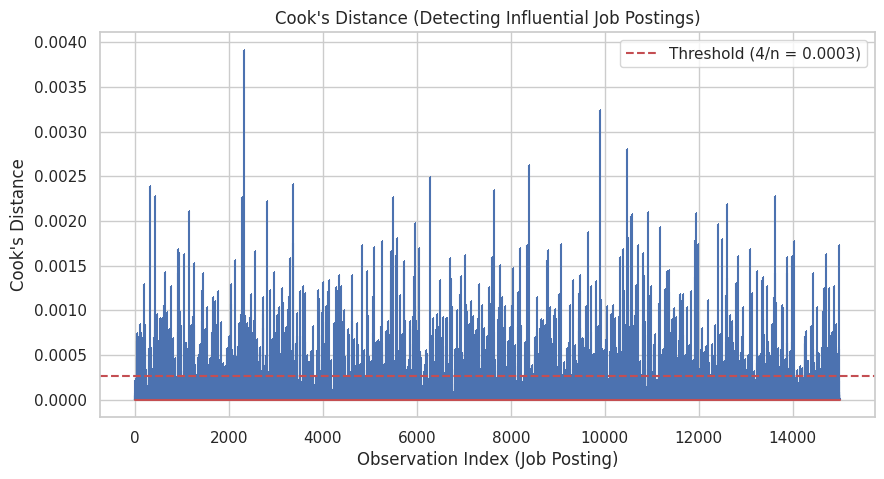

Found 1166 highly influential job postings.


,salary_usd,years_experience,benefits_score,experience_level,education_required,company_size,is_remote
37,111381,18,8.1,EX,Master,S,0
48,288815,12,7.2,EX,Bachelor,S,0
49,124871,19,8.0,EX,PhD,M,0
51,115376,17,5.5,EX,Master,M,1
67,316182,12,7.0,EX,Associate,M,0


In [16]:
# ==========================================
# LEVERAGE & INFLUENTIAL POINTS (Problem Set 4)
# ==========================================
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Fit a standard OLS model on continuous variables
X_influence = sm.add_constant(df_clean[['years_experience', 'benefits_score']])
model_influence = sm.OLS(df_clean['salary_usd'], X_influence).fit()

# Calculate Influence and Cook's Distance
influence = model_influence.get_influence()
cooks_d = influence.cooks_distance[0]

# Plot Cook's Distance
plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Cook's Distance (Detecting Influential Job Postings)")
plt.xlabel("Observation Index (Job Posting)")
plt.ylabel("Cook's Distance")

# Draw a threshold line (A common rule of thumb is 4/n)
threshold = 4 / len(X_influence)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold (4/n = {threshold:.4f})')
plt.legend()
plt.show()

# Print out the highly influential rows
influential_points = df_clean.iloc[np.where(cooks_d > threshold)[0]]
print(f"Found {len(influential_points)} highly influential job postings.")
display(influential_points.head())

In [17]:
# ==========================================
# MULTI-CATEGORY LOGISTIC REGRESSION (Problem Set 6)
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("--- Multi-Category (Multinomial) Logistic Regression ---")

# X = Continuous variables, y = Categorical Experience Level
X_multi = df_clean[['salary_usd', 'years_experience', 'benefits_score']]
y_multi = df_clean['experience_level']

# Split and scale
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=123)
scaler_m = StandardScaler()
X_m_train_scaled = scaler_m.fit_transform(X_m_train)
X_m_test_scaled = scaler_m.transform(X_m_test)

# Fit Multinomial Logistic Regression (multi_class='multinomial')
# Using 'lbfgs' solver which handles multinomial loss well
multi_log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
multi_log_reg.fit(X_m_train_scaled, y_m_train)

# Predict and Evaluate
multi_preds = multi_log_reg.predict(X_m_test_scaled)
print("Classification Report (Predicting Experience Level):")
print(classification_report(y_m_test, multi_preds))

--- Multi-Category (Multinomial) Logistic Regression ---
Classification Report (Predicting Experience Level):
              precision    recall  f1-score   support

          EN       1.00      1.00      1.00       734
          EX       1.00      0.99      1.00       789
          MI       1.00      1.00      1.00       723
          SE       0.99      1.00      1.00       754

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [18]:
# ==========================================
# STATISTICAL SIMULATION (Problem Set 2)
# ==========================================
import numpy as np
import statsmodels.api as sm

print("--- Simulating Least Squares Estimators ---")

np.random.seed(123)
n = 50
R = 1000

# True population parameters
true_beta_0 = 2
true_beta_1 = 3

beta_0_estimates = []
beta_1_estimates = []

# Run the simulation 1000 times
for _ in range(R):
    # Step 1: Generate X from Uniform(0,1), Error from N(0,1)
    x = np.random.uniform(0, 1, n)
    error = np.random.normal(0, 1, n)

    # Generate Y based on true population line
    y = true_beta_0 + (true_beta_1 * x) + error

    # Step 2: Fit Least Squares
    X_sim = sm.add_constant(x)
    model_sim = sm.OLS(y, X_sim).fit()

    # Store the estimated coefficients
    beta_0_estimates.append(model_sim.params[0])
    beta_1_estimates.append(model_sim.params[1])

# Calculate the average of our 1000 estimates
avg_beta_0 = np.mean(beta_0_estimates)
avg_beta_1 = np.mean(beta_1_estimates)

print(f"True Beta 0: {true_beta_0} | Average Estimated Beta 0: {avg_beta_0:.4f}")
print(f"True Beta 1: {true_beta_1} | Average Estimated Beta 1: {avg_beta_1:.4f}")
print("Conclusion: Because the average estimates perfectly match the true values, Least Squares estimators are UNBIASED.")

--- Simulating Least Squares Estimators ---
True Beta 0: 2 | Average Estimated Beta 0: 2.0119
True Beta 1: 3 | Average Estimated Beta 1: 2.9734
Conclusion: Because the average estimates perfectly match the true values, Least Squares estimators are UNBIASED.
